# Batch classification + per-cell / per-blob / per-FOV outputs

Run a frozen U-Net + watershed instance segmentation + crop extraction +
classifier over an input folder whose **subfolders are conditions**.

### Outputs (next to `INPUT_FOLDER`)

| file | format | content |
|---|---|---|
| `per_fov.parquet` | parquet | one row per image; counts, mean p(sickle), filtered protrusion length, polymer area fraction, skeleton metrics |
| `per_condition.parquet` | parquet | one row per condition; sums + medians |
| `per_cell.parquet` | parquet | one row per kept cell; predicted label, p_sickle, full-instance geometry (area, eccentricity, axis_ratio, solidity, compactness), convexity-defect metrics, assigned protrusion length |
| `per_cell_morphology.pt` | torch | `{"features": Tensor[N,30], "feature_names": [...], "row_idx": Tensor[N]}` row-aligned with `per_cell.parquet` via `row_idx` |
| `polymer_blobs.parquet` | parquet | one row per polymer connected component; geometry, distance to cell, assigned instance, `kept` + `drop_reason` (`too_short`, `too_long`, `too_far`) |
| `pairwise_stats.parquet` | parquet | Mann-Whitney + BH-FDR across all comparable per-FOV metrics |
| `manifest.json` | json | config snapshot + checkpoint SHA-256 + per-condition totals |
| `failed.jsonl` | jsonl | one line per FOV that errored |
| `figures/*.svg/.png` | matplotlib | `svg.fonttype='none'` so text remains editable |
| `figures/polymer_qa/<condition>_<stem>.png` | png | first FOV per condition with any dropped blob, colored by drop reason |
| `crops/<condition>/<class>_<stem>_<iid>.jpg` | jpg | optional per-cell visual; `SAVE_CROPS=True` |

Edit the **CONFIG** cell and Run All.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

# ===========================================================================
# REQUIRED — point at the input folder + checkpoints
# ===========================================================================
INPUT_FOLDER          = Path(r"E:/utku g leica/rbc-class/sickling-poster")
UNET_CHECKPOINT       = REPO_ROOT / "models" / "unet_fold_1_best_loop_5.pth"
CLF_CHECKPOINT        = REPO_ROOT / "checkpoints" / "multimodal_dinov2_frozen_image+morphology_fold0" / "last.ckpt"

CLF_VARIANT           = "multimodal"      # "dinov2_frozen" | "timm_vit" | "mae" | "multimodal"
CLF_IMAGE_VARIANT     = "dinov2_frozen"   # only used when CLF_VARIANT == "multimodal"
CLF_USE_IMAGE         = True
CLF_USE_MORPHOLOGY    = True
CLF_MAE_INIT_CKPT     = None

# ===========================================================================
# WORKFLOW
# ===========================================================================
SAVE_CROPS            = True
OVERWRITE_H5          = False             # re-run the U-Net even if PRED_*.h5 exists
BATCH_SIZE            = 64
IMAGE_EXTS            = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

# ===========================================================================
# STATS
# ===========================================================================
PVALUE_TEST           = "mannwhitneyu"    # | "ttest_ind" | "ranksums"
FDR_METHOD            = "fdr_bh"          # | None

# ===========================================================================
# POLYMER — class indices, scale, artifact filter
# ===========================================================================
POLYMER_CLASS_INDEX           = 0
BACKGROUND_CLASS_INDEX        = 1
CELL_BODY_CLASS_INDEX         = 2
CELL_BORDER_CLASS_INDEX       = 3
POLYMER_PX_TO_UM              = 500.0 / 3100.0    # 40x Leica reference: 500 um per 3100 px

# A blob is kept only if all of the following hold:
#   POLYMER_MIN_LENGTH_PX <= major_axis_px <= POLYMER_MAX_LENGTH_PX
#   min(distance from any blob pixel to cell tissue) <= POLYMER_MAX_DIST_FROM_CELL_PX
# Cell tissue = U-Net classes {cell_body, cell_border}.
POLYMER_MIN_LENGTH_PX         = 10
POLYMER_MAX_LENGTH_PX         = 300       # ~48 um — well above expected biological max
POLYMER_MAX_DIST_FROM_CELL_PX = 200       # generous; fragmented fibers can have far ends
POLYMER_ASSIGN_DILATION_PX    = 2         # dilate blob mask before reading instance_image

# ===========================================================================
# CONVEXITY DEFECTS — classifier-free sickle proxy
# ===========================================================================
DEFECT_DEPTH_MIN_PX           = 2         # ignore notches <= 1 px (segmentation noise)

# ---------------------------------------------------------------------------
LABEL_TO_INT = {"non_sickle": 0, "sickle": 1}
INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}
SICKLE_CLASS_INDEX = 1
# ---------------------------------------------------------------------------

print("INPUT_FOLDER    :", INPUT_FOLDER)
print("UNET            :", UNET_CHECKPOINT)
print("CLF_CHECKPOINT  :", CLF_CHECKPOINT)
print("CLF_VARIANT     :", CLF_VARIANT, "(image_variant=%s, image=%s, morph=%s)" % (
    CLF_IMAGE_VARIANT, CLF_USE_IMAGE, CLF_USE_MORPHOLOGY))
print("SAVE_CROPS      :", SAVE_CROPS, "| OVERWRITE_H5:", OVERWRITE_H5)
print("p-value test    :", PVALUE_TEST, "| FDR method:", FDR_METHOD)
print("polymer scale   :", f"{POLYMER_PX_TO_UM:.5f} um/px")
print("polymer filter  :", f"len in [{POLYMER_MIN_LENGTH_PX},{POLYMER_MAX_LENGTH_PX}] px, dist<={POLYMER_MAX_DIST_FROM_CELL_PX} px")
print("defect min depth:", DEFECT_DEPTH_MIN_PX, "px")
assert INPUT_FOLDER.exists(), f"INPUT_FOLDER not found: {INPUT_FOLDER}"
assert UNET_CHECKPOINT.exists(), f"UNET_CHECKPOINT not found: {UNET_CHECKPOINT}"
assert CLF_CHECKPOINT.exists(), f"CLF_CHECKPOINT not found: {CLF_CHECKPOINT}"

INPUT_FOLDER    : E:\utku g leica\rbc-class\sickling-poster
UNET            : E:\utku g leica\rbc-class\models\unet_fold_1_best_loop_5.pth
CLF_CHECKPOINT  : E:\utku g leica\rbc-class\checkpoints\multimodal_dinov2_frozen_image+morphology_fold0\last.ckpt
CLF_VARIANT     : multimodal (image_variant=dinov2_frozen, image=True, morph=True)
SAVE_CROPS      : True | OVERWRITE_H5: False
p-value test    : mannwhitneyu | FDR method: fdr_bh
polymer scale   : 0.16129 um/px
polymer filter  : len in [10,300] px, dist<=200 px
defect min depth: 2 px


## Load the U-Net and the classifier

`sickling.config.load_config()` supplies the channel layout, crop size,
percentile normalisation, and instance-segmentation hyperparameters.

In [3]:
import numpy as np
import torch

from sickling.rbc_classification.py_modules.config import load_config
from sickling.rbc_classification.py_modules.stage1_unet import load_unet
from sickling.rbc_classification.py_modules.stage4_repr import build_encoder
from sickling.rbc_classification.py_modules.stage4_repr.finetune import FinetuneModule
from sickling.rbc_classification.py_modules.stage4_repr.linear_probe import LinearProbeModule
from sickling.rbc_classification.py_modules.stage5_multimodal.classifier import MultimodalClassifier
from sickling.rbc_classification.py_modules.stage5_multimodal.image_tower import ImageTower
from sickling.rbc_classification.py_modules.stage5_multimodal.lightning_module import MultimodalFinetuneModule
from sickling.rbc_classification.py_modules.stage5_multimodal.morphology_features import N_FEATURES
from sickling.rbc_classification.py_modules.stage5_multimodal.morphology_tower import MorphologyTower

cfg = load_config()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

unet = load_unet(UNET_CHECKPOINT, n_classes=4, device=DEVICE)
unet.eval()
print("U-Net loaded.")


def _build_image_module(variant, mae_init_ckpt=None):
    encoder = build_encoder(variant)
    if variant == "mae" and mae_init_ckpt is not None:
        from sickling.rbc_classification.py_modules.stage4_repr.timm_vit_encoder import MAEViTEncoder
        assert isinstance(encoder, MAEViTEncoder)
        encoder.load_mae_checkpoint(mae_init_ckpt)
    if variant == "dinov2_frozen":
        return LinearProbeModule(encoder=encoder)
    return FinetuneModule(encoder=encoder)


def _build_multimodal_module(image_variant, use_image, use_morphology,
                              n_morph_features=N_FEATURES, mae_init_ckpt=None):
    towers = {}
    if use_image:
        encoder = build_encoder(image_variant)
        if image_variant == "mae" and mae_init_ckpt is not None:
            from sickling.rbc_classification.py_modules.stage4_repr.timm_vit_encoder import MAEViTEncoder
            assert isinstance(encoder, MAEViTEncoder)
            encoder.load_mae_checkpoint(mae_init_ckpt)
        towers["image"] = ImageTower(encoder)
    if use_morphology:
        towers["morphology"] = MorphologyTower(in_features=n_morph_features)
    classifier = MultimodalClassifier(
        towers,
        num_classes=cfg.multimodal.num_classes,
        hidden=cfg.multimodal.fusion_hidden,
        dropout=cfg.multimodal.dropout,
    )
    return MultimodalFinetuneModule(classifier=classifier)


if CLF_VARIANT == "multimodal":
    module = _build_multimodal_module(
        image_variant=CLF_IMAGE_VARIANT,
        use_image=CLF_USE_IMAGE,
        use_morphology=CLF_USE_MORPHOLOGY,
        mae_init_ckpt=CLF_MAE_INIT_CKPT,
    )
else:
    module = _build_image_module(CLF_VARIANT, mae_init_ckpt=CLF_MAE_INIT_CKPT)

state = torch.load(CLF_CHECKPOINT, map_location="cpu", weights_only=False)
missing, unexpected = module.load_state_dict(state["state_dict"], strict=False)
if missing:
    print(f"  WARNING: {len(missing)} state_dict keys missing (often OK for frozen encoder).")
if unexpected:
    print(f"  WARNING: {len(unexpected)} state_dict keys unexpected.")
module = module.to(DEVICE).eval()
print(f"Classifier loaded: {CLF_VARIANT}")

device: cuda
U-Net loaded.


Using cache found in C:\Users\Leica-Admin/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Leica-Admin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Leica-Admin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Leica-Admin/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Classifier loaded: multimodal


## Per-image pipeline

For each raw image:
1. Load + percentile-normalise the greyscale.
2. Predict the 4-class U-Net label map (cache to `<condition>/h5/PRED_<stem>.h5`).
3. Watershed → integer instance label image.
4. **Polymer analysis** — connected components on U-Net class 0; per-blob:
   major-axis length (µm), distance to nearest cell tissue pixel, mode-assigned
   instance id. Filter by `[MIN_LENGTH, MAX_LENGTH]` and `MAX_DIST_FROM_CELL`.
   Per-FOV aggregates: total length, area fraction, skeleton length,
   skeleton endpoints, skeleton branch points (all computed on the kept-blob
   mask only).
5. **Cell geometry** — `regionprops` on each kept instance (full mask, not
   the 96×96 crop) plus a convex-hull-defect pass for the spike count and
   max defect depth.
6. Extract 3-channel 96×96 crops, batch-forward through the classifier, keep
   p(sickle) and the 30-D morphology feature vector.
7. Optionally save per-cell JPGs.

In [4]:
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import binary_dilation, convolve, distance_transform_edt
from skimage.measure import label as sklabel
from skimage.measure import regionprops
from skimage.morphology import convex_hull_image, skeletonize
from tqdm.auto import tqdm

from sickling.rbc_classification.py_modules.data.crop_dataset import _resize_3channel
from sickling.rbc_classification.py_modules.io.h5 import load_label_map, write_ilastik_h5
from sickling.rbc_classification.py_modules.io.images import load_raw_greyscale, normalize_image
from sickling.rbc_classification.py_modules.stage1_unet import predict_label_map
from sickling.rbc_classification.py_modules.stage2_instances.watershed import mask_to_instances
from sickling.rbc_classification.py_modules.stage3_crops.extract import extract_for_fov
from sickling.rbc_classification.py_modules.stage5_multimodal.morphology_features import FEATURE_NAMES, compute_features


def _ensure_h5(raw_path, h5_dir):
    h5_dir.mkdir(parents=True, exist_ok=True)
    out_h5 = h5_dir / f"PRED_{raw_path.stem}.h5"
    if out_h5.exists() and not OVERWRITE_H5:
        return out_h5
    raw = load_raw_greyscale(raw_path)
    raw_norm = normalize_image(raw, cfg.crop.norm_percentile)
    label_map = predict_label_map(unet, raw_norm, n_classes=4)
    write_ilastik_h5(out_h5, (label_map.astype(np.int32) + 1).astype(np.uint8))
    return out_h5


def _convexity_defects(mask):
    """Count and depth-rank inward concavities in a binary cell mask.

    Concavity = convex_hull(mask) XOR mask. For each connected concavity
    region, depth = max EDT(~mask) within it (perpendicular distance
    from the original boundary). Defects with depth < DEFECT_DEPTH_MIN_PX
    are ignored.

    Returns (n_defects, max_depth_px).
    """
    if mask.sum() < 4:
        return 0, 0.0
    hull = convex_hull_image(mask)
    defect = hull & ~mask
    if not defect.any():
        return 0, 0.0
    dist = distance_transform_edt(~mask)
    defect_labels = sklabel(defect, connectivity=2)
    n_kept = 0
    max_depth = 0.0
    for rp in regionprops(defect_labels, intensity_image=dist):
        depth = float(rp.intensity_max)
        if depth >= DEFECT_DEPTH_MIN_PX:
            n_kept += 1
            if depth > max_depth:
                max_depth = depth
    return n_kept, max_depth


def _extract_cell_geometry(instance_image):
    """Per-instance geometry computed on the FULL instance mask (not 96x96)."""
    out = {}
    for rp in regionprops(instance_image):
        iid = int(rp.label)
        area = int(rp.area)
        perim = float(rp.perimeter)
        compactness = perim ** 2 / (4 * np.pi * area) if (area > 0 and perim > 0) else float("nan")
        major = float(rp.major_axis_length)
        minor = float(rp.minor_axis_length)
        axis_ratio = major / minor if minor > 0 else float("nan")
        n_def, max_depth_px = _convexity_defects(rp.image)
        out[iid] = {
            "area_px": area,
            "eccentricity": float(rp.eccentricity),
            "axis_ratio": axis_ratio,
            "solidity": float(rp.solidity),
            "compactness": compactness,
            "n_convexity_defects": int(n_def),
            "max_defect_depth_um": float(max_depth_px) * POLYMER_PX_TO_UM,
        }
    return out


def _analyze_polymer(label_map, instance_image):
    """Per-blob records + per-FOV polymer aggregates (kept blobs only).

    Cell tissue := U-Net classes {cell_body, cell_border}. The distance gate
    uses min(dist from any blob pixel to nearest cell tissue pixel), so a
    long fiber whose centroid is far from a cell but whose tip touches one
    still passes.
    """
    poly_mask = label_map == POLYMER_CLASS_INDEX
    cell_tissue_mask = (
        (label_map == CELL_BODY_CLASS_INDEX) | (label_map == CELL_BORDER_CLASS_INDEX)
    )
    cell_tissue_px = int(cell_tissue_mask.sum())

    zero_fov = {
        "polymer_length_um": 0.0,
        "n_polymer_blobs_kept": 0,
        "n_polymer_blobs_dropped_too_short": 0,
        "n_polymer_blobs_dropped_too_long": 0,
        "n_polymer_blobs_dropped_too_far": 0,
        "polymer_area_fraction": 0.0,
        "polymer_skeleton_length_um": 0.0,
        "polymer_endpoints": 0,
        "polymer_branch_points": 0,
    }
    if not poly_mask.any():
        return [], zero_fov

    components = sklabel(poly_mask, connectivity=2)
    # EDT from the inverse of cell tissue: dist_to_cell[y,x] = distance to
    # nearest cell-tissue pixel (0 inside tissue itself).
    dist_to_cell = distance_transform_edt(~cell_tissue_mask) if cell_tissue_px else np.full_like(
        poly_mask, fill_value=1e6, dtype=np.float32
    )

    records = []
    for rp in regionprops(components):
        blob_pixels = (components == rp.label)
        major_px = float(rp.major_axis_length)
        min_dist_px = float(dist_to_cell[blob_pixels].min())

        # Assign to the instance covering the most pixels in a small dilation.
        dilated = binary_dilation(blob_pixels, iterations=POLYMER_ASSIGN_DILATION_PX)
        ins_vals = instance_image[dilated]
        ins_vals = ins_vals[ins_vals > 0]
        assigned = int(np.bincount(ins_vals).argmax()) if ins_vals.size else None

        if major_px < POLYMER_MIN_LENGTH_PX:
            kept, reason = False, "too_short"
        elif major_px > POLYMER_MAX_LENGTH_PX:
            kept, reason = False, "too_long"
        elif min_dist_px > POLYMER_MAX_DIST_FROM_CELL_PX:
            kept, reason = False, "too_far"
        else:
            kept, reason = True, ""

        records.append({
            "blob_id": int(rp.label),
            "major_um": major_px * POLYMER_PX_TO_UM,
            "minor_um": float(rp.minor_axis_length) * POLYMER_PX_TO_UM,
            "area_px": int(rp.area),
            "eccentricity": float(rp.eccentricity) if rp.area > 1 else 0.0,
            "solidity": float(rp.solidity) if rp.area > 1 else 1.0,
            "dist_to_cell_px": min_dist_px,
            "assigned_instance_id": assigned,
            "kept": kept,
            "drop_reason": reason,
        })

    kept = [r for r in records if r["kept"]]
    dropped_counts = {
        f"n_polymer_blobs_dropped_{r}": sum(1 for x in records if x["drop_reason"] == r)
        for r in ("too_short", "too_long", "too_far")
    }
    kept_ids = [r["blob_id"] for r in kept]
    kept_mask = np.isin(components, kept_ids) if kept_ids else np.zeros_like(poly_mask, dtype=bool)
    kept_px = int(kept_mask.sum())

    skel = skeletonize(kept_mask)
    if skel.any():
        kern = np.ones((3, 3), dtype=int)
        neigh = convolve(skel.astype(int), kern, mode="constant", cval=0) - skel.astype(int)
        endpoints = int(((neigh == 1) & skel).sum())
        branchpoints = int(((neigh >= 3) & skel).sum())
    else:
        endpoints = 0
        branchpoints = 0

    per_fov = {
        "polymer_length_um": sum(r["major_um"] for r in kept),
        "n_polymer_blobs_kept": len(kept),
        **dropped_counts,
        "polymer_area_fraction": kept_px / max(kept_px + cell_tissue_px, 1),
        "polymer_skeleton_length_um": int(skel.sum()) * POLYMER_PX_TO_UM,
        "polymer_endpoints": endpoints,
        "polymer_branch_points": branchpoints,
    }
    return records, per_fov


@torch.no_grad()
def _classify_crops(tensors_96):
    """Return (pred_labels[N], p_sickle[N], morph_features[N, 30]).

    Morphology features are computed on the original 96x96 crop (before resize
    to the ViT input size) so the mask channels stay binary.
    """
    if tensors_96.numel() == 0:
        return (
            np.empty((0,), dtype=np.int64),
            np.empty((0,), dtype=np.float32),
            np.empty((0, len(FEATURE_NAMES)), dtype=np.float32),
        )

    resized = torch.stack([_resize_3channel(t, cfg.crop.resize_to_vit) for t in tensors_96])
    morph_full = np.stack([compute_features(t) for t in tensors_96]).astype(np.float32)

    pred_out = []
    p_sickle_out = []
    for start in range(0, resized.shape[0], BATCH_SIZE):
        batch = resized[start : start + BATCH_SIZE].to(DEVICE, non_blocking=True)
        if CLF_VARIANT == "multimodal":
            inputs = {}
            if CLF_USE_IMAGE:
                inputs["image"] = batch
            if CLF_USE_MORPHOLOGY:
                inputs["morphology"] = torch.from_numpy(
                    morph_full[start : start + batch.shape[0]]
                ).to(DEVICE, non_blocking=True)
            logits = module(inputs)
        else:
            logits = module(batch)
        probs = F.softmax(logits.float(), dim=-1).detach().cpu().numpy()
        pred_out.append(probs.argmax(axis=-1))
        p_sickle_out.append(probs[:, SICKLE_CLASS_INDEX])
    return np.concatenate(pred_out), np.concatenate(p_sickle_out), morph_full


def _save_crops(tensors_96, pred, instance_ids, crops_condition_dir, stem):
    crops_condition_dir.mkdir(parents=True, exist_ok=True)
    for t, lbl, iid in zip(tensors_96, pred, instance_ids, strict=True):
        cls = INT_TO_LABEL[int(lbl)]
        arr = np.clip(t[0].detach().cpu().numpy(), 0.0, 1.0) * 255.0
        Image.fromarray(arr.astype(np.uint8), mode="L").save(
            crops_condition_dir / f"{cls}_{stem}_{int(iid)}.jpg",
            quality=92,
        )


def process_image(raw_path, h5_dir, crops_condition_dir):
    """Run the full per-image pipeline. Returns a dict with keys:
       per_fov (dict), per_cell (list[dict]), per_blob (list[dict]),
       morph (np.ndarray[N, 30]).
    """
    stem = raw_path.stem
    h5_path = _ensure_h5(raw_path, h5_dir)
    label_map = load_label_map(h5_path, n_classes=4)
    raw_norm = normalize_image(load_raw_greyscale(raw_path), cfg.crop.norm_percentile)
    if label_map.shape != raw_norm.shape:
        raise ValueError(f"shape mismatch: label_map={label_map.shape} raw={raw_norm.shape}")

    instance_image, _stats = mask_to_instances(label_map, cfg.instances, cfg.classes)

    blob_records, polymer_fov = _analyze_polymer(label_map, instance_image)
    cell_geom = _extract_cell_geometry(instance_image)

    assigned_polymer_um = {}
    for r in blob_records:
        if not r["kept"] or r["assigned_instance_id"] is None:
            continue
        iid = r["assigned_instance_id"]
        assigned_polymer_um[iid] = assigned_polymer_um.get(iid, 0.0) + r["major_um"]

    tensors, instance_ids, _kept_meta, _failed_meta = extract_for_fov(
        raw_norm=raw_norm,
        label_map=label_map,
        instance_image=instance_image,
        cfg=cfg.crop,
        classes=cfg.classes,
    )

    if tensors.shape[0] == 0:
        return {
            "per_fov": {
                "n_sickle": 0, "n_non_sickle": 0, "n_cells": 0,
                "mean_p_sickle": float("nan"), "frac_sickle": float("nan"),
                **polymer_fov,
                "polymer_um_per_100_cells": float("nan"),
            },
            "per_cell": [],
            "per_blob": blob_records,
            "morph": np.empty((0, len(FEATURE_NAMES)), dtype=np.float32),
        }

    pred, p_sickle, morph = _classify_crops(tensors)
    n_s = int((pred == LABEL_TO_INT["sickle"]).sum())
    n_n = int((pred == LABEL_TO_INT["non_sickle"]).sum())

    if SAVE_CROPS:
        _save_crops(tensors, pred, instance_ids, crops_condition_dir, stem)

    per_cell = []
    for i, iid in enumerate(instance_ids):
        g = cell_geom.get(int(iid), {})
        per_cell.append({
            "instance_id": int(iid),
            "predicted_label": INT_TO_LABEL[int(pred[i])],
            "p_sickle": float(p_sickle[i]),
            "assigned_polymer_length_um": float(assigned_polymer_um.get(int(iid), 0.0)),
            "area_px": g.get("area_px"),
            "eccentricity": g.get("eccentricity"),
            "axis_ratio": g.get("axis_ratio"),
            "solidity": g.get("solidity"),
            "compactness": g.get("compactness"),
            "n_convexity_defects": g.get("n_convexity_defects"),
            "max_defect_depth_um": g.get("max_defect_depth_um"),
        })

    n_cells = n_s + n_n
    per_fov = {
        "n_sickle": n_s,
        "n_non_sickle": n_n,
        "n_cells": n_cells,
        "mean_p_sickle": float(p_sickle.mean()),
        "frac_sickle": (n_s / n_cells) if n_cells > 0 else float("nan"),
        **polymer_fov,
        "polymer_um_per_100_cells": (
            polymer_fov["polymer_length_um"] * 100.0 / n_cells if n_cells > 0 else float("nan")
        ),
    }
    return {"per_fov": per_fov, "per_cell": per_cell, "per_blob": blob_records, "morph": morph}

## Walk every condition subfolder and collect records

In [5]:
import pandas as pd

condition_dirs = sorted(
    p for p in INPUT_FOLDER.iterdir()
    if p.is_dir() and p.name not in ("crops", "figures")
)
if not condition_dirs:
    raise FileNotFoundError(f"No condition subfolders under {INPUT_FOLDER}.")

crops_root = INPUT_FOLDER / "crops"
if SAVE_CROPS:
    crops_root.mkdir(parents=True, exist_ok=True)

fov_records = []
cell_records = []
blob_records = []
morph_chunks = []
failed = []

# row_idx links per_cell.parquet rows <-> per_cell_morphology.pt rows.
global_row_idx = 0

print(f"Processing {len(condition_dirs)} conditions ...")
for cond_dir in condition_dirs:
    condition = cond_dir.name
    h5_dir = cond_dir / "h5"
    crops_condition_dir = crops_root / condition

    raw_files = []
    for ext in IMAGE_EXTS:
        raw_files.extend(sorted(cond_dir.glob(f"*{ext}")))
    if not raw_files:
        print(f"  [{condition}] no images found, skipping.")
        continue

    for raw_path in tqdm(raw_files, desc=condition, leave=False):
        try:
            out = process_image(raw_path, h5_dir, crops_condition_dir)
        except Exception as e:
            failed.append({"condition": condition, "image": raw_path.name, "error": repr(e)})
            print(f"  [{condition}/{raw_path.name}] FAILED: {e!r}")
            continue

        stem = raw_path.stem
        fov_records.append({
            "condition": condition,
            "image_name": raw_path.name,
            "stem": stem,
            **out["per_fov"],
        })
        for c in out["per_cell"]:
            cell_records.append({
                "condition": condition,
                "image_name": raw_path.name,
                "stem": stem,
                "row_idx": global_row_idx,
                **c,
            })
            global_row_idx += 1
        for b in out["per_blob"]:
            blob_records.append({
                "condition": condition,
                "image_name": raw_path.name,
                "stem": stem,
                **b,
            })
        if out["morph"].size:
            morph_chunks.append(out["morph"])

    n_done = sum(1 for r in fov_records if r["condition"] == condition)
    print(f"  [{condition}] {n_done} images recorded.")

per_fov_df = pd.DataFrame(fov_records)
per_cell_df = pd.DataFrame(cell_records)
per_blob_df = pd.DataFrame(blob_records)
morph_matrix = (
    np.concatenate(morph_chunks, axis=0)
    if morph_chunks else np.empty((0, len(FEATURE_NAMES)), dtype=np.float32)
)

assert len(per_cell_df) == len(morph_matrix), (
    f"row_idx alignment broken: {len(per_cell_df)} cells vs {len(morph_matrix)} morph rows"
)

print()
print("per_fov_df :", per_fov_df.shape)
print("per_cell_df:", per_cell_df.shape)
print("per_blob_df:", per_blob_df.shape)
print("morph      :", morph_matrix.shape)
print("failed     :", len(failed))

Processing 8 conditions ...


A-UNT:   0%|          | 0/288 [00:00<?, ?it/s]

  [A-UNT] 288 images recorded.


ALHi:   0%|          | 0/288 [00:00<?, ?it/s]

  [ALHi] 288 images recorded.


...

  [SE2] 288 images recorded.


SLHi:   0%|          | 0/288 [00:00<?, ?it/s]

  [SLHi] 288 images recorded.


SLN1:   0%|          | 0/288 [00:00<?, ?it/s]

  [SLN1] 288 images recorded.

per_fov_df : (3008, 18)
per_cell_df: (215363, 15)
per_blob_df: (101679, 13)
morph      : (215363, 30)
failed     : 0


## Write parquet / pt / json / jsonl outputs

In [6]:
import hashlib
import json
from datetime import datetime, timezone

OUT_PER_FOV    = INPUT_FOLDER / "per_fov.parquet"
OUT_PER_COND   = INPUT_FOLDER / "per_condition.parquet"
OUT_PER_CELL   = INPUT_FOLDER / "per_cell.parquet"
OUT_PER_BLOB   = INPUT_FOLDER / "polymer_blobs.parquet"
OUT_MORPH      = INPUT_FOLDER / "per_cell_morphology.pt"
OUT_STATS      = INPUT_FOLDER / "pairwise_stats.parquet"
OUT_MANIFEST   = INPUT_FOLDER / "manifest.json"
OUT_FAILED     = INPUT_FOLDER / "failed.jsonl"
FIGURES_DIR    = INPUT_FOLDER / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "polymer_qa").mkdir(parents=True, exist_ok=True)

per_fov_df.to_parquet(OUT_PER_FOV, index=False)
per_cell_df.to_parquet(OUT_PER_CELL, index=False)
per_blob_df.to_parquet(OUT_PER_BLOB, index=False)

torch.save({
    "features": torch.from_numpy(morph_matrix),
    "feature_names": list(FEATURE_NAMES),
    "row_idx": torch.arange(len(morph_matrix), dtype=torch.int64),
}, OUT_MORPH)

# ----- per_condition aggregates -------------------------------------------
fov_agg = per_fov_df.groupby("condition", sort=True).agg(
    n_images=("image_name", "count"),
    n_sickle=("n_sickle", "sum"),
    n_non_sickle=("n_non_sickle", "sum"),
    n_cells=("n_cells", "sum"),
    polymer_length_um_sum=("polymer_length_um", "sum"),
    polymer_skeleton_length_um_sum=("polymer_skeleton_length_um", "sum"),
    polymer_endpoints_sum=("polymer_endpoints", "sum"),
    polymer_branch_points_sum=("polymer_branch_points", "sum"),
    n_polymer_blobs_kept_sum=("n_polymer_blobs_kept", "sum"),
    n_polymer_blobs_dropped_too_short=("n_polymer_blobs_dropped_too_short", "sum"),
    n_polymer_blobs_dropped_too_long=("n_polymer_blobs_dropped_too_long", "sum"),
    n_polymer_blobs_dropped_too_far=("n_polymer_blobs_dropped_too_far", "sum"),
    median_frac_sickle=("frac_sickle", "median"),
    median_mean_p_sickle=("mean_p_sickle", "median"),
    median_polymer_um_per_100_cells=("polymer_um_per_100_cells", "median"),
    median_polymer_area_fraction=("polymer_area_fraction", "median"),
).reset_index()

cell_medians = per_cell_df.groupby("condition", sort=True).agg(
    median_eccentricity=("eccentricity", "median"),
    median_axis_ratio=("axis_ratio", "median"),
    median_solidity=("solidity", "median"),
    median_compactness=("compactness", "median"),
    median_n_convexity_defects=("n_convexity_defects", "median"),
    median_max_defect_depth_um=("max_defect_depth_um", "median"),
).reset_index()

per_condition_df = fov_agg.merge(cell_medians, on="condition", how="left")
per_condition_df.to_parquet(OUT_PER_COND, index=False)

# ----- failed.jsonl -------------------------------------------------------
with open(OUT_FAILED, "w") as f:
    for row in failed:
        f.write(json.dumps(row) + "\n")


def _sha256(p, chunk=1 << 20):
    h = hashlib.sha256()
    with open(p, "rb") as fh:
        while True:
            b = fh.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


manifest = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "input_folder": str(INPUT_FOLDER),
    "checkpoints": {
        "unet": {"path": str(UNET_CHECKPOINT), "sha256": _sha256(UNET_CHECKPOINT)},
        "classifier": {
            "path": str(CLF_CHECKPOINT),
            "sha256": _sha256(CLF_CHECKPOINT),
            "variant": CLF_VARIANT,
            "image_variant": CLF_IMAGE_VARIANT,
            "use_image": CLF_USE_IMAGE,
            "use_morphology": CLF_USE_MORPHOLOGY,
        },
    },
    "config": {
        "polymer_px_to_um": POLYMER_PX_TO_UM,
        "polymer_min_length_px": POLYMER_MIN_LENGTH_PX,
        "polymer_max_length_px": POLYMER_MAX_LENGTH_PX,
        "polymer_max_dist_from_cell_px": POLYMER_MAX_DIST_FROM_CELL_PX,
        "polymer_assign_dilation_px": POLYMER_ASSIGN_DILATION_PX,
        "defect_depth_min_px": DEFECT_DEPTH_MIN_PX,
        "batch_size": BATCH_SIZE,
        "pvalue_test": PVALUE_TEST,
        "fdr_method": FDR_METHOD,
    },
    "conditions": (
        per_fov_df.groupby("condition")
        .agg(n_images=("image_name", "count"), n_cells=("n_cells", "sum"))
        .reset_index()
        .to_dict(orient="records")
    ),
    "outputs": {
        "per_fov": str(OUT_PER_FOV),
        "per_condition": str(OUT_PER_COND),
        "per_cell": str(OUT_PER_CELL),
        "per_cell_morphology": str(OUT_MORPH),
        "polymer_blobs": str(OUT_PER_BLOB),
        "pairwise_stats": str(OUT_STATS),
        "failed": str(OUT_FAILED),
        "figures_dir": str(FIGURES_DIR),
    },
    "failed_count": len(failed),
}
with open(OUT_MANIFEST, "w") as f:
    json.dump(manifest, f, indent=2)

print("wrote:")
for k, v in manifest["outputs"].items():
    print(f"  {k}: {v}")
print(f"  manifest: {OUT_MANIFEST}")
print(f"  failed:   {len(failed)} entries")

wrote:
  per_fov: E:\utku g leica\rbc-class\sickling-poster\per_fov.parquet
  per_condition: E:\utku g leica\rbc-class\sickling-poster\per_condition.parquet
  per_cell: E:\utku g leica\rbc-class\sickling-poster\per_cell.parquet
  per_cell_morphology: E:\utku g leica\rbc-class\sickling-poster\per_cell_morphology.pt
  polymer_blobs: E:\utku g leica\rbc-class\sickling-poster\polymer_blobs.parquet
  pairwise_stats: E:\utku g leica\rbc-class\sickling-poster\pairwise_stats.parquet
  failed: E:\utku g leica\rbc-class\sickling-poster\failed.jsonl
  figures_dir: E:\utku g leica\rbc-class\sickling-poster\figures
  manifest: E:\utku g leica\rbc-class\sickling-poster\manifest.json
  failed:   0 entries


## Pairwise statistics

Mann-Whitney U (two-sided, non-paired) by default, optional t-test or
Wilcoxon rank-sums. Benjamini-Hochberg FDR is applied within each metric
across the pair set.

Per-FOV metrics tested: `frac_sickle`, `mean_p_sickle`, `polymer_um_per_100_cells`,
`polymer_area_fraction`, `polymer_skeleton_length_um`. Per-cell metrics are
aggregated to per-FOV medians before testing: `eccentricity`, `axis_ratio`,
`solidity`, `compactness`, `n_convexity_defects`, `max_defect_depth_um`.

In [7]:
from itertools import combinations
from scipy import stats as _stats


def _bh_fdr(pvalues):
    arr = np.asarray(pvalues, dtype=float)
    out = np.full_like(arr, np.nan)
    mask = ~np.isnan(arr)
    if mask.sum() == 0:
        return out
    p = arr[mask]
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    adj_sorted = p[order] * n / ranks
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    adj_sorted = np.clip(adj_sorted, 0.0, 1.0)
    adjusted = np.empty(n, dtype=float)
    adjusted[order] = adj_sorted
    out[mask] = adjusted
    return out


def _pvalue(a, b):
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    if PVALUE_TEST == "mannwhitneyu":
        return float(_stats.mannwhitneyu(a, b, alternative="two-sided").pvalue)
    if PVALUE_TEST == "ttest_ind":
        return float(_stats.ttest_ind(a, b, equal_var=False).pvalue)
    if PVALUE_TEST == "ranksums":
        return float(_stats.ranksums(a, b).pvalue)
    raise ValueError(f"Unknown PVALUE_TEST={PVALUE_TEST!r}")


conditions = sorted(per_fov_df["condition"].unique())
cond_idx = {c: i + 1 for i, c in enumerate(conditions)}

FOV_METRICS = [
    "frac_sickle",
    "mean_p_sickle",
    "polymer_um_per_100_cells",
    "polymer_area_fraction",
    "polymer_skeleton_length_um",
]
CELL_METRICS = [
    "eccentricity",
    "axis_ratio",
    "solidity",
    "compactness",
    "n_convexity_defects",
    "max_defect_depth_um",
]

# Aggregate per-cell metrics to per-FOV medians for the FOV-level tests.
per_fov_cell_medians = (
    per_cell_df.groupby(["condition", "image_name"])[CELL_METRICS]
    .median()
    .reset_index()
    .rename(columns={c: f"median_{c}" for c in CELL_METRICS})
)
combined = per_fov_df.merge(per_fov_cell_medians, on=["condition", "image_name"], how="left")

pairs = list(combinations(conditions, 2))
all_metrics = FOV_METRICS + [f"median_{c}" for c in CELL_METRICS]

stats_rows = []
for metric in all_metrics:
    raw_p = []
    for a, b in pairs:
        va = combined.loc[combined["condition"] == a, metric].dropna().to_numpy()
        vb = combined.loc[combined["condition"] == b, metric].dropna().to_numpy()
        raw_p.append(_pvalue(va, vb))
    fdr_p = (
        _bh_fdr(np.asarray(raw_p, dtype=float)).tolist()
        if FDR_METHOD == "fdr_bh" else [float("nan")] * len(raw_p)
    )
    for (a, b), p, p_fdr in zip(pairs, raw_p, fdr_p, strict=True):
        stats_rows.append({
            "metric": metric,
            "condition_1_index": cond_idx[a],
            "condition_2_index": cond_idx[b],
            "condition_1_name": a,
            "condition_2_name": b,
            "p_value": p,
            "p_value_fdr": p_fdr,
            "test": PVALUE_TEST,
            "fdr_method": str(FDR_METHOD),
        })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_parquet(OUT_STATS, index=False)
print(f"wrote {OUT_STATS}: {len(stats_df)} rows ({len(all_metrics)} metrics x {len(pairs)} pairs)")
display(stats_df.head(15))

wrote E:\utku g leica\rbc-class\sickling-poster\pairwise_stats.parquet: 308 rows (11 metrics x 28 pairs)


,metric,condition_1_index,condition_2_index,condition_1_name,condition_2_name,p_value,p_value_fdr,test,fdr_method
0,frac_sickle,1,2,A-UNT,ALHi,3.326027e-01,3.581875e-01,mannwhitneyu,fdr_bh
1,frac_sickle,1,3,A-UNT,ALLo,5.536506e-01,5.741562e-01,mannwhitneyu,fdr_bh
2,frac_sickle,1,4,A-UNT,S-UNT,4.118127e-87,3.843585e-86,mannwhitneyu,fdr_bh
3,frac_sickle,1,5,A-UNT,SE1,2.227075e-23,5.196508e-23,mannwhitneyu,fdr_bh
4,frac_sickle,1,6,A-UNT,SE2,9.768574e-06,1.439579e-05,mannwhitneyu,fdr_bh
5,frac_sickle,1,7,A-UNT,SLHi,7.434491e-53,3.469429e-52,mannwhitneyu,fdr_bh
6,frac_sickle,1,8,A-UNT,SLN1,1.900919e-32,5.913971e-32,mannwhitneyu,fdr_bh
7,frac_sickle,2,3,ALHi,ALLo,1.382769e-01,1.548701e-01,mannwhitneyu,fdr_bh
8,frac_sickle,2,4,ALHi,S-UNT,6.038394e-108,1.690750e-106,mannwhitneyu,fdr_bh
9,frac_sickle,2,5,ALHi,SE1,6.522213e-26,1.660200e-25,mannwhitneyu,fdr_bh


## Figures

All SVGs render with `svg.fonttype='none'` and PDF with `fonttype=42` so
text remains editable in Illustrator / Inkscape.

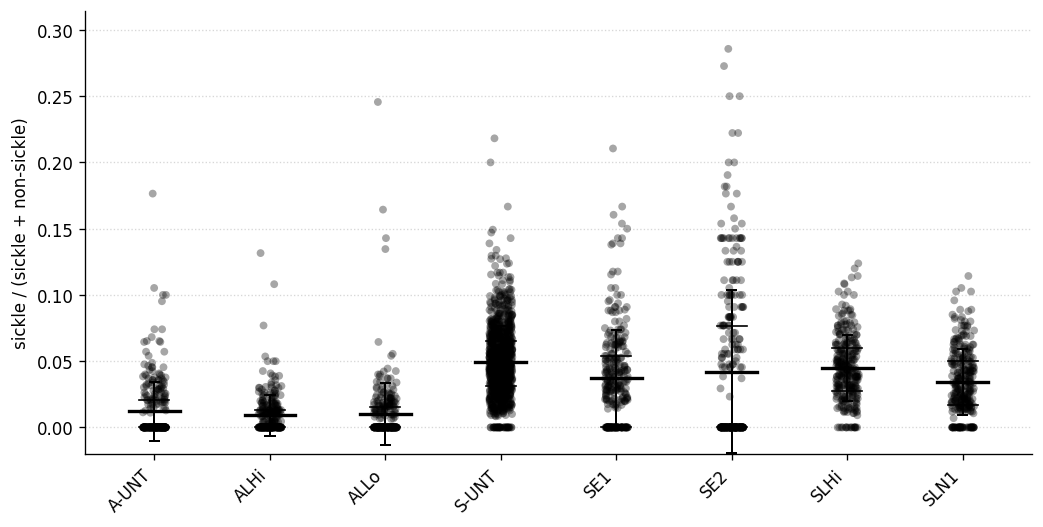

wrote E:\utku g leica\rbc-class\sickling-poster\figures\scatter_frac_sickle.svg


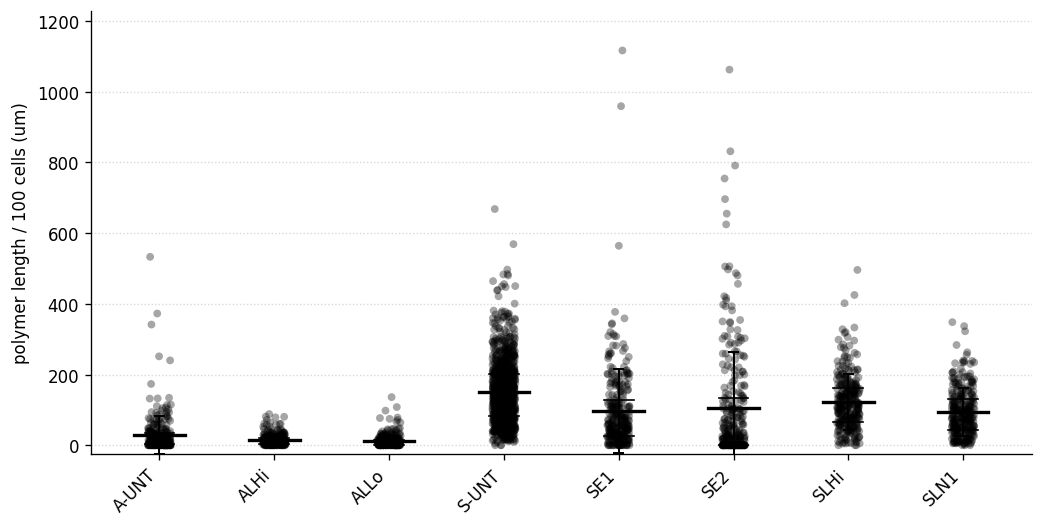

wrote E:\utku g leica\rbc-class\sickling-poster\figures\scatter_polymer_per_100_cells.svg


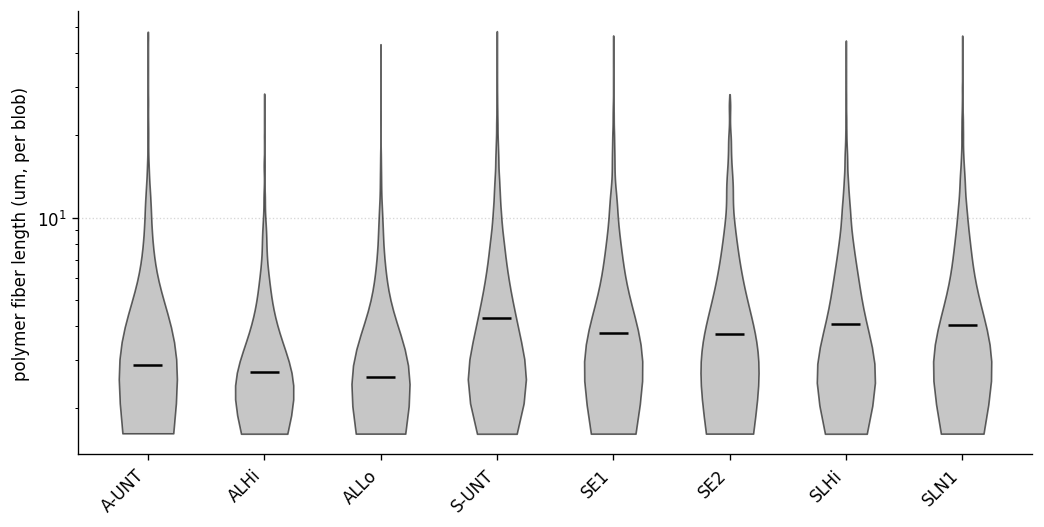

wrote E:\utku g leica\rbc-class\sickling-poster\figures\violin_polymer_length.svg


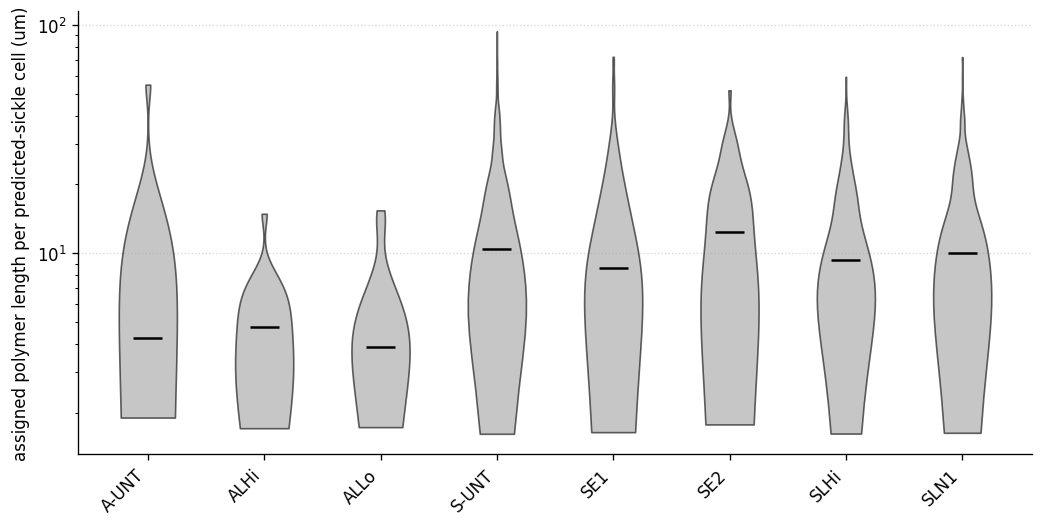

wrote E:\utku g leica\rbc-class\sickling-poster\figures\violin_severity.svg


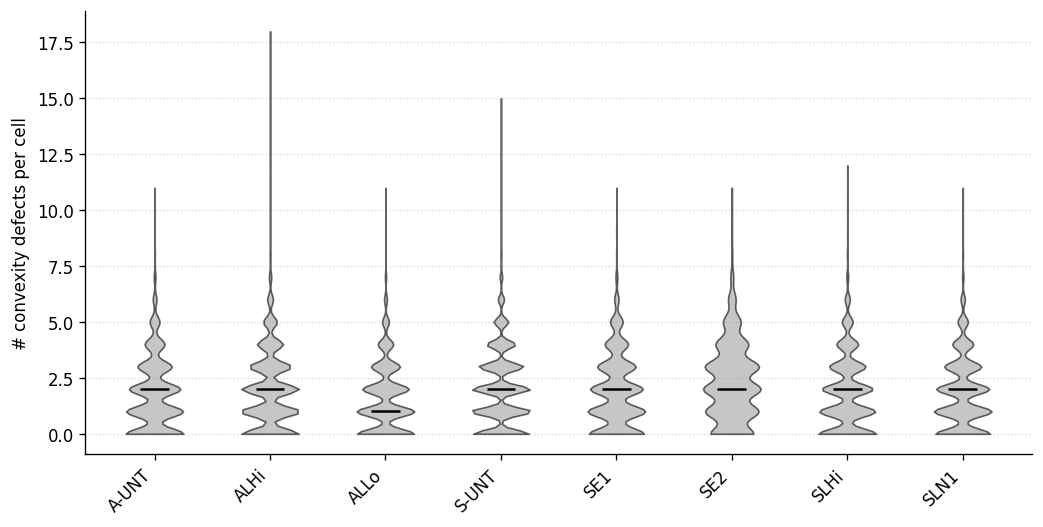

wrote E:\utku g leica\rbc-class\sickling-poster\figures\violin_convexity_defects.svg


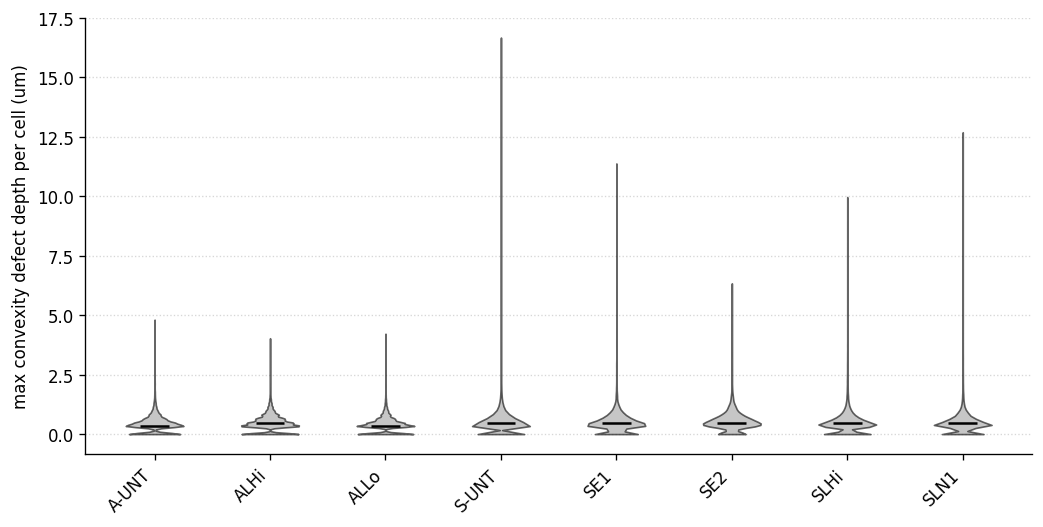

wrote E:\utku g leica\rbc-class\sickling-poster\figures\violin_max_defect_depth.svg


In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42


def _column_scatter(groups, labels, ylabel, ylim, out_svg, out_png, seed=0):
    rng = np.random.default_rng(seed)
    fig_w = max(4.5, 1.1 * len(labels))
    fig, ax = plt.subplots(figsize=(fig_w, 4.5), dpi=120)
    JITTER, MEAN_HW, QUART_HW, CAP = 0.10, 0.22, 0.13, 0.04
    for i, (lab, vals) in enumerate(zip(labels, groups, strict=True)):
        x = i + 1
        if vals.size == 0:
            continue
        jitter = rng.uniform(-JITTER, JITTER, size=vals.size)
        ax.scatter(np.full_like(vals, x) + jitter, vals, s=22, color="black",
                   alpha=0.35, edgecolors="none", zorder=2)
        mean = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
        q1 = float(np.quantile(vals, 0.25))
        q3 = float(np.quantile(vals, 0.75))
        ax.plot([x, x], [mean - sd, mean + sd], color="black", lw=1.2, zorder=3)
        ax.plot([x - CAP, x + CAP], [mean - sd, mean - sd], color="black", lw=1.2, zorder=3)
        ax.plot([x - CAP, x + CAP], [mean + sd, mean + sd], color="black", lw=1.2, zorder=3)
        ax.plot([x - QUART_HW, x + QUART_HW], [q1, q1], color="black", lw=1.0, zorder=4)
        ax.plot([x - QUART_HW, x + QUART_HW], [q3, q3], color="black", lw=1.0, zorder=4)
        ax.plot([x - MEAN_HW, x + MEAN_HW], [mean, mean], color="black", lw=2.0, zorder=5)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0.4, len(labels) + 0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(out_svg)
    fig.savefig(out_png, dpi=200)
    plt.show()
    print(f"wrote {out_svg}")


def _violin(groups, labels, ylabel, out_svg, out_png, log_y=False, ylim=None):
    if log_y:
        groups = [g[g > 0] for g in groups]
    fig_w = max(4.5, 1.1 * len(labels))
    fig, ax = plt.subplots(figsize=(fig_w, 4.5), dpi=120)
    valid_positions = [i + 1 for i, g in enumerate(groups) if g.size > 0]
    valid_groups = [g for g in groups if g.size > 0]
    if valid_groups:
        parts = ax.violinplot(valid_groups, positions=valid_positions,
                              showmeans=False, showextrema=False, showmedians=True)
        for pc in parts["bodies"]:
            pc.set_facecolor("#a0a0a0")
            pc.set_edgecolor("black")
            pc.set_alpha(0.6)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    if log_y:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0.4, len(labels) + 0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", alpha=0.5)
    fig.tight_layout()
    fig.savefig(out_svg)
    fig.savefig(out_png, dpi=200)
    plt.show()
    print(f"wrote {out_svg}")


# --- scatter: per-FOV sickle fraction -------------------------------------
sickle_groups = [
    per_fov_df.loc[per_fov_df["condition"] == c, "frac_sickle"].dropna().to_numpy()
    for c in conditions
]
all_sickle = np.concatenate(sickle_groups) if sickle_groups else np.array([0.0])
y_top_s = float(np.nanmax(all_sickle) * 1.1) if all_sickle.size else 0.22
_column_scatter(
    sickle_groups, conditions,
    "sickle / (sickle + non-sickle)",
    (-0.02, max(0.22, y_top_s)),
    FIGURES_DIR / "scatter_frac_sickle.svg",
    FIGURES_DIR / "scatter_frac_sickle.png",
    seed=0,
)

# --- scatter: per-FOV polymer length per 100 cells (filtered) -------------
poly_groups = [
    per_fov_df.loc[per_fov_df["condition"] == c, "polymer_um_per_100_cells"].dropna().to_numpy()
    for c in conditions
]
all_p = np.concatenate(poly_groups) if poly_groups else np.array([0.0])
y_top_p = float(np.nanmax(all_p) * 1.1) if all_p.size else 1.0
_column_scatter(
    poly_groups, conditions,
    "polymer length / 100 cells (um)",
    (-0.02 * y_top_p, max(y_top_p, 1.0)),
    FIGURES_DIR / "scatter_polymer_per_100_cells.svg",
    FIGURES_DIR / "scatter_polymer_per_100_cells.png",
    seed=1,
)

# --- violin: per-blob polymer length (kept blobs only, log-y) -------------
kept_blob_df = per_blob_df[per_blob_df["kept"]] if not per_blob_df.empty else per_blob_df
blob_len_groups = [
    kept_blob_df.loc[kept_blob_df["condition"] == c, "major_um"].to_numpy()
    for c in conditions
]
_violin(
    blob_len_groups, conditions,
    "polymer fiber length (um, per blob)",
    FIGURES_DIR / "violin_polymer_length.svg",
    FIGURES_DIR / "violin_polymer_length.png",
    log_y=True,
)

# --- violin: per-cell assigned polymer length, predicted-sickle cells -----
sickle_cells = per_cell_df[per_cell_df["predicted_label"] == "sickle"]
severity_groups = [
    sickle_cells.loc[sickle_cells["condition"] == c, "assigned_polymer_length_um"].to_numpy()
    for c in conditions
]
_violin(
    severity_groups, conditions,
    "assigned polymer length per predicted-sickle cell (um)",
    FIGURES_DIR / "violin_severity.svg",
    FIGURES_DIR / "violin_severity.png",
    log_y=True,
)

# --- violin: # convexity defects per cell --------------------------------
defect_groups = [
    per_cell_df.loc[per_cell_df["condition"] == c, "n_convexity_defects"].dropna().to_numpy()
    for c in conditions
]
_violin(
    defect_groups, conditions,
    "# convexity defects per cell",
    FIGURES_DIR / "violin_convexity_defects.svg",
    FIGURES_DIR / "violin_convexity_defects.png",
)

# --- violin: max convexity defect depth per cell -------------------------
depth_groups = [
    per_cell_df.loc[per_cell_df["condition"] == c, "max_defect_depth_um"].dropna().to_numpy()
    for c in conditions
]
_violin(
    depth_groups, conditions,
    "max convexity defect depth per cell (um)",
    FIGURES_DIR / "violin_max_defect_depth.svg",
    FIGURES_DIR / "violin_max_defect_depth.png",
)

## Protrusion filter QA

For each condition, render the first FOV with any dropped blobs. Kept blobs
are green; dropped blobs are colored by reason
(`too_short`=blue, `too_long`=orange, `too_far`=red). Use these to sanity-check
`POLYMER_*` thresholds before quoting numbers in a paper.

In [9]:
def _polymer_qa_figure(condition, stem, raw_path):
    blobs = per_blob_df[
        (per_blob_df["condition"] == condition) & (per_blob_df["stem"] == stem)
    ]
    if blobs.empty or not (~blobs["kept"]).any():
        return None

    h5_path = INPUT_FOLDER / condition / "h5" / f"PRED_{stem}.h5"
    label_map = load_label_map(h5_path, n_classes=4)
    raw = load_raw_greyscale(raw_path)
    raw_norm = normalize_image(raw, cfg.crop.norm_percentile)
    poly_mask = label_map == POLYMER_CLASS_INDEX
    components = sklabel(poly_mask, connectivity=2)

    REASON_COLORS = {
        "": (0.1, 0.9, 0.1),         # kept
        "too_short": (0.3, 0.7, 1.0),
        "too_long": (1.0, 0.65, 0.0),
        "too_far": (1.0, 0.2, 0.2),
    }
    overlay = np.repeat(raw_norm[..., None], 3, axis=-1).astype(np.float32)
    for _, r in blobs.iterrows():
        mask = components == int(r["blob_id"])
        color = REASON_COLORS.get(r["drop_reason"], (1.0, 1.0, 1.0))
        for ch in range(3):
            overlay[..., ch] = np.where(
                mask, 0.45 * overlay[..., ch] + 0.55 * color[ch], overlay[..., ch]
            )

    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)
    ax.imshow(np.clip(overlay, 0, 1))
    ax.set_title(
        f"{condition} / {stem}\n"
        "green=kept   blue=too_short   orange=too_long   red=too_far",
        fontsize=10,
    )
    ax.set_axis_off()
    out = FIGURES_DIR / "polymer_qa" / f"{condition}_{stem}.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out


qa_paths = []
for cond_dir in condition_dirs:
    condition = cond_dir.name
    raw_files = []
    for ext in IMAGE_EXTS:
        raw_files.extend(sorted(cond_dir.glob(f"*{ext}")))
    for raw_path in raw_files:
        out = _polymer_qa_figure(condition, raw_path.stem, raw_path)
        if out is not None:
            qa_paths.append(out)
            print(f"  QA: {out}")
            break

print(f"\nQA figures written: {len(qa_paths)} / {len(condition_dirs)}")

  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\A-UNT_D10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\ALHi_E10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\ALLo_F10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\S-UNT_D18_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\SE1_G10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\SE2_H10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\SLHi_K10_03_1_10_Bright Field_001.png
  QA: E:\utku g leica\rbc-class\sickling-poster\figures\polymer_qa\SLN1_I10_03_1_10_Bright Field_001.png

QA figures written: 8 / 8


## Summary

In [10]:
print("Input folder            :", INPUT_FOLDER)
print("Conditions processed    :", len(conditions))
print("Images recorded (total) :", len(per_fov_df))
print("Cells recorded          :", len(per_cell_df))
print("Polymer blobs recorded  :", len(per_blob_df))
if not per_blob_df.empty:
    print(f"  kept                : {int((per_blob_df['kept']).sum())}")
    print(f"  dropped (too_short) : {int((per_blob_df['drop_reason'] == 'too_short').sum())}")
    print(f"  dropped (too_long)  : {int((per_blob_df['drop_reason'] == 'too_long').sum())}")
    print(f"  dropped (too_far)   : {int((per_blob_df['drop_reason'] == 'too_far').sum())}")
print("Failed images           :", len(failed))
print()
print("Outputs:")
for k, v in manifest["outputs"].items():
    print(f"  {k}: {v}")
print(f"  manifest: {OUT_MANIFEST}")
if SAVE_CROPS:
    n_crop_files = sum(1 for _ in (INPUT_FOLDER / "crops").rglob("*.jpg"))
    print(f"  crops/   : {n_crop_files} jpg files across {len(conditions)} condition subfolders")

Input folder            : E:\utku g leica\rbc-class\sickling-poster
Conditions processed    : 8
Images recorded (total) : 3008
Cells recorded          : 215363
Polymer blobs recorded  : 101679
  kept                : 36389
  dropped (too_short) : 64947
  dropped (too_long)  : 29
  dropped (too_far)   : 314
Failed images           : 0

Outputs:
  per_fov: E:\utku g leica\rbc-class\sickling-poster\per_fov.parquet
  per_condition: E:\utku g leica\rbc-class\sickling-poster\per_condition.parquet
  per_cell: E:\utku g leica\rbc-class\sickling-poster\per_cell.parquet
  per_cell_morphology: E:\utku g leica\rbc-class\sickling-poster\per_cell_morphology.pt
  polymer_blobs: E:\utku g leica\rbc-class\sickling-poster\polymer_blobs.parquet
  pairwise_stats: E:\utku g leica\rbc-class\sickling-poster\pairwise_stats.parquet
  failed: E:\utku g leica\rbc-class\sickling-poster\failed.jsonl
  figures_dir: E:\utku g leica\rbc-class\sickling-poster\figures
  manifest: E:\utku g leica\rbc-class\sickling-post